# Exercício Avaliativo: Q-learning

## Setup

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Any

### Classe `GridWorldMDP`

In [2]:
class GridWorldMDP:
    def __init__(
            self,
            shape=(3,4),
            goal=(0,3),
            traps=[(1,3)],
            terminals=[(0,3), (1,3)],
            obstacles=[(1,1)],
            goal_reward=10,
            trap_reward=-10
        ) -> None:
        self.shape = shape
        self.goal = goal                # Posição da grid
        self.traps = traps              # Posição da grid
        self.terminals = terminals      # Posição da grid
        self.obstacles = obstacles      # Posição da grid
        self.goal_reward = goal_reward  # Recompensa
        self.trap_reward = trap_reward  # Recompensa

    def get_reward(self, state) -> int:
        if state == self.goal:
            return self.goal_reward
        elif state in self.traps:
            return self.trap_reward
        else:
            return 0

    def is_valid_state(self, state) -> bool:
        i, j = state
        if i < 0 or i >= self.shape[0] or j < 0 or j >= self.shape[1]:
            return False
        if state in self.obstacles:
            return False
        return True

    def next_state(self, state, action) -> tuple[Any, Any]:
        # Ações:
        #   0 = Cima        ↑
        #   1 = Baixo       ↓
        #   2 = Esquerda    ←
        #   3 = Direita     →
        moves = {
            0: (-1, 0),
            1: (1, 0),
            2: (0, -1),
            3: (0, 1)
        }

        di, dj = moves[action]
        next_s = (state[0] + di, state[1] + dj)

        if not self.is_valid_state(next_s):
            return state
        return next_s

    def state_to_index(self, state) -> Any:
        i, j = state
        return i * self.shape[1] + j

    def index_to_state(self, index) -> tuple[Any, Any]:
        i = index // self.shape[1]
        j = index % self.shape[1]
        return (i, j)

    def random_valid_state(self) -> tuple[Any, Any]:
      while True:
          i = np.random.randint(self.shape[0])
          j = np.random.randint(self.shape[1])
          s = (i, j)

          if s not in self.obstacles and s not in self.terminals:
              return s

### Função para Visualizar o Grid World

In [3]:
def plot_gridworld(env, policy=None, values=None) -> None:
    rows, cols = env.shape[0], env.shape[1]
    arrow_dirs = {
      0: (-1, 0),  # Cima       ↑
      1: (1, 0),   # Baixo      ↓
      2: (0, -1),  # Esquerda   ←
      3: (0, 1),   # Direita    →
    }
    
    _, ax = plt.subplots(figsize=(cols, rows))

    for x in range(rows + 1):
        ax.axhline(x, lw=1, color="black")
    for y in range(cols + 1):
        ax.axvline(y, lw=1, color="black")

    for i in range(rows):
        for j in range(cols):
            y = rows - i - 1
            state = (i, j)

            if state in env.obstacles:
                color = "black"
            else:
                color = "white"

            ax.add_patch(plt.Rectangle((j, y), 1, 1, color=color))  # type: ignore (Pylance)

            if state == env.goal or state in env.traps:
                reward = env.get_reward(state)
                ax.text(
                    j + 0.5,
                    y + 0.3,
                    f"{reward}",
                    ha="center",
                    va="center",
                    fontsize=14,
                    color="black"
                )

            if state in env.terminals:
                ax.text(
                    j + 0.5,
                    y + 0.6,
                    "Term",
                    ha="center",
                    va="center",
                    fontsize=14,
                    color="black"
                )
            state_index = env.state_to_index(state)

            if values is not None and state not in env.terminals and state not in env.obstacles:
                val = values[state_index]
                ax.text(
                    j + 0.5,
                    y + 0.1,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="blue"
                )

            if policy is not None and state not in env.terminals and state not in env.obstacles:
                action = policy[state_index]
                dx, dy = arrow_dirs[action]
                ax.arrow(
                    j + 0.5,
                    y + 0.5,
                    dy * 0.3,
                    -dx * 0.3,
                    head_width=0.2,
                    head_length=0.2,
                    fc="black",
                    ec="black"
                )

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("")

    plt.show()

Visualizar o Grid World

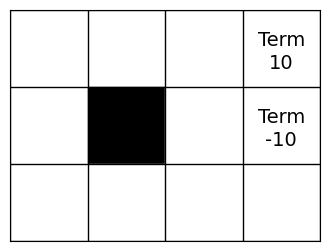

In [4]:
env = GridWorldMDP()
plot_gridworld(env)

## Exercício Prático

### 1. Implementar o Algoritmo _Q-learning_

A lógica do algoritmo é a seguinte:
1. Inicializar a Q-Table (zerada)
2. Escolher um estado inicial
3. Escolher uma ação para executar
4. Medir a recompensa obtida ao executar a ação
5. Atualizar a Q-Table para o estado e ação escolhidos
6. Repetir os passos 2 a 5 até chegar em um estado terminal
7. Iniciar um novo episódio (passos 2 a 6) até que o número de episódios estabelecidos seja atingido

Para escolher uma ação, inicialmente usaremos a estratégia $ϵ$-greedy. Ela consiste em tentar equilibrar e descobrir novas informações sobre o ambiente ou ir atrás de maximizar a recompensa. Ela pode ser formalizada da seguinte forma:

$$A_t ← \begin{cases}
\arg\max_a Q_t(a) & \text{com probabilidade } 1 - \epsilon \\
\text{random}(a_1, \dots, a_k) & \text{com probabilidade } \epsilon
\end{cases}$$

Nesse caso, o $ϵ$ define o quanto o nosso agente vai procurar explorar ou ir atrás de maximizar a recompensa. Se fizermos que esse valor diminua ao longo do tempo, podemos estimular que o agente priorize a exploração no início, mas depois busque maximizar a recompensa ao longo da execução do algoritmo.

In [5]:
n_actions = 4
n_states = env.shape[0] * env.shape[1]

Q = np.zeros((n_states, n_actions))

In [6]:
def epsilon_greedy(Q, state_idx, epsilon):
    if np.random.rand() < epsilon:
      return np.random.randint(n_actions)
    else:
      return np.argmax(Q[state_idx])

Aqui implementamos o funcionamento do algoritmo, como o passo a passo listado anteriormente.

No passo 5, devemos atualizar a Q-Table conforme o que foi observado pelo agente, mais uma vez usando o princípio da **Equação de Bellman**:

$$Q(S_t,A_t) ← Q(S_t, A_t) + α [R_{t+1} + γ\ max_aQ(S_{t+1},a) - Q(S_t, A_t)]$$

Lembrando que $α$ é a taxa de aprendizado do algoritmo, e $γ$ o fator de desconto de recompensas futuras.

In [7]:
def train_q_learning(
        env,
        episodes=500,
        alpha=0.1,
        gamma=0.9,
        epsilon=0.2
    ):
    Q = np.zeros((n_states, n_actions))

    for _ in range(episodes):
        state = env.random_valid_state()

        while True:
            s_idx = env.state_to_index(state)

            # Escolher uma ação:
            action = epsilon_greedy(Q, s_idx, epsilon)

            # Executar ação:
            next_state = env.next_state(state, action)
            reward = env.get_reward(next_state)
            next_idx = env.state_to_index(next_state)

            # Atualizar Q-Table:
            Q[s_idx, action] += alpha * (reward + gamma * max(Q[next_idx]) - Q[s_idx, action])
            state = next_state

            # Parar episódio quando chegar num estado terminal:
            if state in env.terminals:
                break
    return Q

In [8]:
def extract_policy(Q, env):
    policy = np.zeros(env.shape[0] * env.shape[1])

    for i in range(env.shape[0]):
        for j in range(env.shape[1]):
            state = (i, j)

            if state in env.obstacles or state in env.terminals:
                continue

            s_idx = env.state_to_index(state)
            policy[s_idx] = np.argmax(Q[s_idx])
    return policy

Agora podemos visualizar o que o algoritmo aprendeu para o nosso caso simples do labirinto:

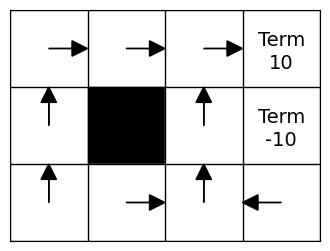

In [9]:
Q = train_q_learning(
    env,
    episodes=2000,
    alpha=0.1,
    gamma=0.9,
    epsilon=0.2
)
policy = extract_policy(Q, env)

plot_gridworld(env, policy=policy)

## Avaliação

### 1 - Crie um ambiente Grid World mais complexo, como por exemplo o que vimos nos exercícios de Value Iteration.

Segue código de exemplo:
```python
env_ex = GridWorldMDP(
    shape=(5,5),
    goal=(2,2),
    traps=[(1,2), (2,1), (3,2)],
    terminals=[(2,2), (1,2), (3,2)],
    obstacles=[(1,1), (3,1), (1,3), (3,3)]
)
plot_gridworld(env_ex)
```

Procure criar um cenário com as seguintes características:
- Tamanho mínimo de 5 x 5
- Um ou mais estados terminais com uma recompensa positiva (`goal`)
- Pelo menos um outro estado com o mesmo valor de recompensa, porém negativo (`traps`) e nenhum estado terminal com recompensa negativa

Execute o algoritmo implementado em aula e observe o que ocorre. Quantos episódios foram necessários para o algoritmo achar uma solução válida?

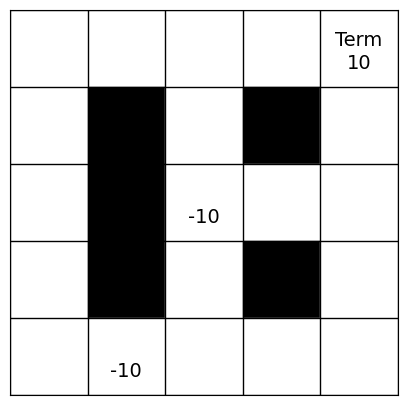

Episódios: 500


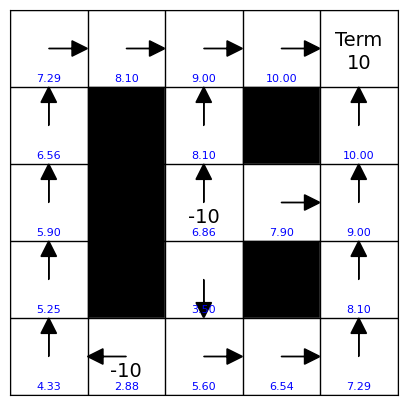

Episódios: 1,000


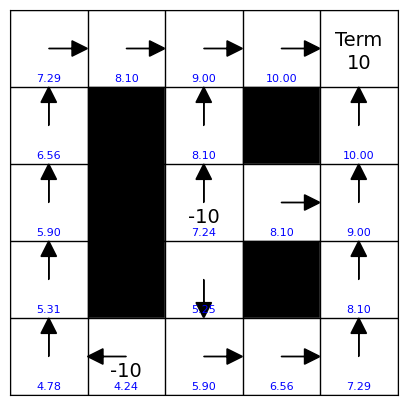

Episódios: 2,000


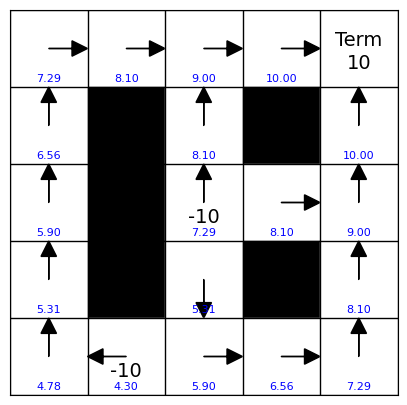

Episódios: 5,000


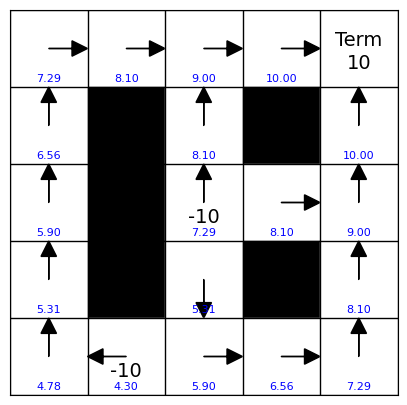

In [10]:
# Utilizando o código de exemplo no enunciado:
new_env = GridWorldMDP(
    shape=(5, 5),  # Ambiente 5x5
    goal=(0, 4),
    traps=[(2, 2), (4, 1)],
    terminals=[(0, 4)],
    obstacles=[(1, 1), (1, 3), (2, 1), (3, 1), (3, 3)],
    goal_reward=10,
    trap_reward=-10,
)

n_states = new_env.shape[0] * new_env.shape[1]
plot_gridworld(new_env)

# Observar em quantos episódios o algoritmo converge para uma política válida:
for n_ep in [500, 1_000, 2_000, 5_000]:
    Q_cx = train_q_learning(
        new_env,
        episodes=n_ep,
        alpha=0.1,
        gamma=0.9,
        epsilon=0.2
    )
    pol_cx = extract_policy(Q_cx, new_env)

    print(f"Episódios: {n_ep:,}")
    plot_gridworld(new_env, policy=pol_cx, values=Q_cx.max(axis=1))

**Resposta**: _O algoritmo levou em torno de 1.000–2.000 episódios para convergir numa política válida, considerando: $ε$=0.2; $α$=0.1 e ambiente=5x5._

---

### 2 - Feito isso, baseada na implementação do Q-learning feita em aula, faça que o agente tenda a explorar menos ao longo do tempo.

Descreva a diferença que essa mudança faz no comportamento do algoritmo.

- Dica: declínio da variável $ϵ$

ε fixo (ε = 0.2 constante) - 2,000 episódios


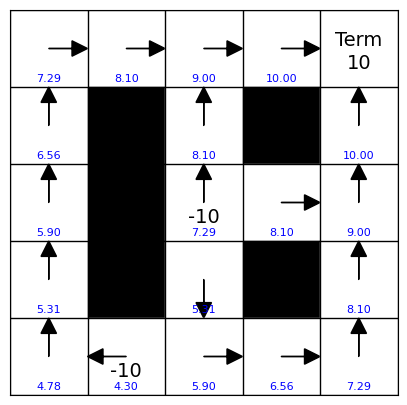

ε com declínio exponencial (1.0 → 0.05) - 2,000 episódios


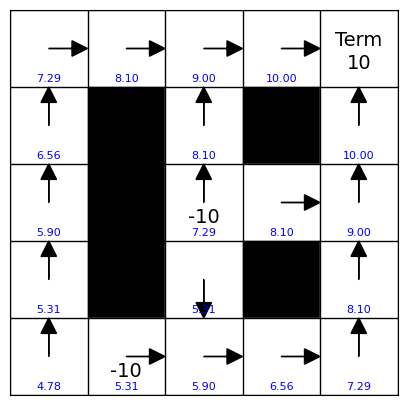

In [11]:
def train_q_learning_epsilon_decay(
        env,
        episodes=2000,
        alpha=0.1,
        gamma=0.9,
        epsilon_start=1.0,
        epsilon_min=0.05,
        decay_rate=0.005,
    ):
    Q = np.zeros((n_states, n_actions))

    for ep in range(episodes):
        # Declínio exponencial
        # Explora bastante no início, explota no final
        epsilon = epsilon_min + (epsilon_start - epsilon_min) * np.exp(-decay_rate * ep)
        state = env.random_valid_state()

        while True:
            s_idx = env.state_to_index(state)
            action = epsilon_greedy(Q, s_idx, epsilon)
            next_state = env.next_state(state, action)
            reward = env.get_reward(next_state)
            next_idx = env.state_to_index(next_state)

            Q[s_idx, action] += alpha * (reward + gamma * max(Q[next_idx]) - Q[s_idx, action])
            state = next_state

            if state in env.terminals:
                break
    return Q


n_ep = 2_000
Q_fixo = train_q_learning(new_env, episodes=n_ep, alpha=0.1, gamma=0.9, epsilon=0.2)
Q_decay = train_q_learning_epsilon_decay(new_env, episodes=n_ep, alpha=0.1, gamma=0.9)


print(f"ε fixo (ε = 0.2 constante) - {n_ep:,} episódios")
plot_gridworld(new_env, policy=extract_policy(Q_fixo, new_env), values=Q_fixo.max(axis=1))

print(f"ε com declínio exponencial (1.0 → 0.05) - {n_ep:,} episódios")
plot_gridworld(new_env, policy=extract_policy(Q_decay, new_env), values=Q_decay.max(axis=1))

**Resposta**

- _Com **ε fixo**, o agente mantém a mesma taxa de exploração durante todo o treinamento_

- _Com o **declínio de ε**, o treinamento ocorre em duas fases:_
    - _Exploração: ε próximo de 1 - O agente visita estados de forma quase aleatória_
    - _Explotação: ε próximo de 0.05 - Com o conhecimento acumulado, o agente passa a seguir a política aprendida na maior parte do tempo_

---

### 3 - Implemente uma visualização (gráfico) que nos permita observar o ganho total de recompensa para cada episódio executado no algoritmo.

Reflita sobre e explique o que isso representa em relação ao _Q-learning_.

In [12]:
def train_q_learning_tracked(
        env,
        episodes=2000,
        alpha=0.1,
        gamma=0.9,
        epsilon=0.2,
        epsilon_start=None,
        epsilon_min=0.05,
        decay_rate=0.005,
    ):
    Q = np.zeros((n_states, n_actions))
    episode_rewards = []

    for episode in range(episodes):
        eps = (
            epsilon
            if epsilon_start is None
            else epsilon_min + (epsilon_start - epsilon_min) * np.exp(-decay_rate * episode)
        )

        state = env.random_valid_state()
        total_reward = 0

        while True:
            s_idx = env.state_to_index(state)
            action = epsilon_greedy(Q, s_idx, eps)
            next_state = env.next_state(state, action)
            reward = env.get_reward(next_state)
            next_idx = env.state_to_index(next_state)

            Q[s_idx, action] += alpha * (reward + gamma * max(Q[next_idx]) - Q[s_idx, action])
            total_reward += reward
            state = next_state

            if state in env.terminals:
                break

        episode_rewards.append(total_reward)
    return Q, episode_rewards


n_ep = 3_000
window = 150


_, rewards_fixo = train_q_learning_tracked(
    new_env,
    episodes=n_ep,
    alpha=0.1,
    gamma=0.9,
    epsilon=0.2
)

_, rewards_decay = train_q_learning_tracked(
    new_env,
    episodes=n_ep,
    alpha=0.1,
    gamma=0.9,
    epsilon_start=1.0
)


avg_fixed = np.convolve(
    rewards_fixo,
    np.ones(window) / window,
    mode="valid"
)

avg_decay = np.convolve(
    rewards_decay,
    np.ones(window) / window,
    mode="valid"
)

x_avg = range(window - 1, n_ep)

Gerar visualização

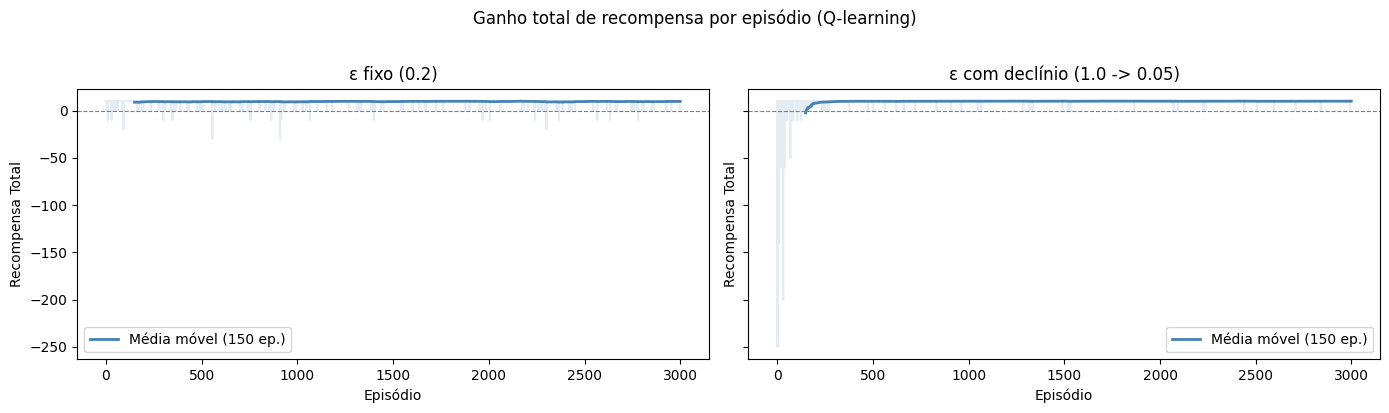

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, rewards, avg, titulo in zip(
    axes,
    [rewards_fixo, rewards_decay],
    [avg_fixed, avg_decay],
    ["ε fixo (0.2)", "ε com declínio (1.0 -> 0.05)"],
):
    ax.plot(rewards, alpha=0.15, color="steelblue")
    ax.plot(x_avg, avg, color="steelblue", linewidth=2, label=f"Média móvel ({window} ep.)")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(titulo)
    ax.set_xlabel("Episódio")
    ax.set_ylabel("Recompensa Total")
    ax.legend()

fig.suptitle("Ganho total de recompensa por episódio (Q-learning)", y=1.02)
plt.tight_layout()
plt.show()

**Resposta**

_Sobre a visualização, o eixo horizontal é o número do episódio e o eixo vertical é a soma de recompensas dentro daquele episódio. A linha pontilhada mostra o valor bruto, e a linha sólida é a média móvel._

_Com isso, é possível observar que:_
- _No início, o agente ainda não aprendeu nada. Portanto, age de forma aleatória e tende a cair em `traps`, além de percorrer caminhos mais longos antes de encontrar o `goal`_
- _Na medida que a Q-Table vai ganhando experiência, o agente vai preferindo ações que priorizam o `goal` a `traps`_
- _Quando a Q-Table converge, a política estabiliza e as recompensas variam em torno de um valor alto. Sinal de que o aprendizado foi concluído_